In [65]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

column_names = [
    "surgery",
    "age",
    "hospital_number",
    "rectal_temperature",
    "pulse",
    "respiratory_rate",
    "temp_of_extremities",
    "peripheral_pulse",
    "mucous_membranes",
    "capillary_refill_time",
    "pain",
    "peristalsis",
    "abdominal_distension",
    "nasogastric_tube",
    "nasogastric_reflux",
    "nasogastric_reflux_ph",
    "rectal_examination_feces",
    "abdomen",
    "packed_cell_volume",
    "total_protein",
    "abdominocentesis_appearance",
    "abdomcentesis_total_protein",
    "outcome",
    "surgical_lesion",
    "lesion_type_1",
    "lesion_type_2",
    "lesion_type_3",
    "cp_data"
]

data_train = pd.read_csv(r'..\data\real data\horse_colic_train.csv')
print(data_train.isnull().sum())

surgery                    0
age                        0
hospital_number            0
rectal_temp               60
pulse                     24
respiratory_rate          58
temp_of_extremities       56
peripheral_pulse          69
mucous_membrane           47
capillary_refill_time     32
pain                      55
peristalsis               44
abdominal_distention      56
nasogastric_tube         104
nasogastric_reflux       106
nasogastric_reflux_ph    246
rectal_exam_feces        102
abdomen                  118
packed_cell_volume        29
total_protein             33
abdomo_appearance        165
abdomo_protein           198
outcome                    0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
dtype: int64


### Pipeline xử lý 
* 1. Describe Data
* 2. Outlier Detection 
* 3. Handle misssing values 
* 4. Normalization 
* 5. Target Encode 


In [66]:
# 1. DESCRIBE DATA
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surgery                299 non-null    object 
 1   age                    299 non-null    object 
 2   hospital_number        299 non-null    int64  
 3   rectal_temp            239 non-null    float64
 4   pulse                  275 non-null    float64
 5   respiratory_rate       241 non-null    float64
 6   temp_of_extremities    243 non-null    object 
 7   peripheral_pulse       230 non-null    object 
 8   mucous_membrane        252 non-null    object 
 9   capillary_refill_time  267 non-null    object 
 10  pain                   244 non-null    object 
 11  peristalsis            255 non-null    object 
 12  abdominal_distention   243 non-null    object 
 13  nasogastric_tube       195 non-null    object 
 14  nasogastric_reflux     193 non-null    object 
 15  nasoga

In [67]:
data_train.describe()

,hospital_number,rectal_temp,pulse,respiratory_rate,nasogastric_reflux_ph,packed_cell_volume,total_protein,abdomo_protein,lesion_1,lesion_2,lesion_3
count,2.990000e+02,239.000000,275.000000,241.000000,53.000000,270.000000,266.000000,101.000000,299.000000,299.000000,299.000000
mean,1.087733e+06,38.168619,72.000000,30.460581,4.707547,46.307407,24.274436,3.039604,3659.709030,90.528428,7.387960
std,1.532032e+06,0.733744,28.646219,17.666102,1.982311,10.436743,27.364194,1.967947,5408.472421,650.637139,127.749768
min,5.184760e+05,35.400000,30.000000,8.000000,1.000000,23.000000,3.300000,0.100000,0.000000,0.000000,0.000000
25%,5.289040e+05,37.800000,48.000000,18.000000,3.000000,38.000000,6.500000,2.000000,2111.500000,0.000000,0.000000
50%,5.303010e+05,38.200000,64.000000,25.000000,5.000000,45.000000,7.500000,2.300000,2322.000000,0.000000,0.000000
75%,5.347360e+05,38.500000,88.000000,36.000000,6.500000,52.000000,56.750000,3.900000,3209.000000,0.000000,0.000000
max,5.305629e+06,40.800000,184.000000,96.000000,7.500000,75.000000,89.000000,10.100000,41110.000000,7111.000000,2209.000000


* 1. hospital_number có outliers bên phải vì giá trị maximum lớn hơn rất nhiều so với phân vị 75%, phương sai lớn, giá trị đơn nhất cao -> thực hiện Encoding. 
* 2. rectal_temp (nhiệt độ trực tràng) : Thông số thống kê bình thường (không có hiện tượng outliers) nhưng phương sai thấp -> phân phối co cụm vào vị trí trung tâm -> Sử dụng Z-score 
* 3. pulse (nhịp tim) : có hiện tượng outliers vì giá trị maximum > bách phân vị 75 % -> Outliers ở trường hợp này là signal chứ không phải noise -> log transformation. 
* 4. respiratory_rate (nhịp thở): có hiện tượng outliers vì giá trị maximum > bách phân vị 75 % -> log transformation 
* 5. nasogastric_reflux_ph (độ pH của dịch trào ngược): Thông số thống kê bình thường nhưng phương sai thấp -> phân phối co cụm vào vị trí trung tâm -> Z-score
* 6. packed_cell_volume (thể tích hồng cầu - đánh giá mức độ mất nước) :  Thông số thống kê bình thường -> Feature tương đối phù hợp cho mô hình học máy 
* 7. total_protein : xuất hiện hiện tượng rời rạc dữ liệu khi mà khoảng cách giữa phân vị 50 và phân vị 75 tương đối lớn -> Sự không đồng nhất về đơn vị đo lường 
* 8. abdomo_protein: xuất hiện outliers trong khi giá trị maximum > tương đối rõ ràng giá trị bách phân vị 75 -> giá trị outlier là singal không phải noise -> log transformation. 
* 9. lesion_1: tổn thương chính thứ nhất - feature này tương tự hospital_number vì là dữ liệu categorical mà được lưu trữ dưới dạng numerical 
* 10. lesion_2 giống feature lesion_1
* 11. lesion_3 giống feature lesion_1

In [68]:
features_to_convert = ['hospital_number', 'lesion_1', 'lesion_2', 'lesion_3']
data_train[features_to_convert] = data_train[features_to_convert].astype('object')

In [69]:
data_train.describe(include=['object', 'category'])

,surgery,age,hospital_number,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,...,nasogastric_reflux,rectal_exam_feces,abdomen,abdomo_appearance,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
count,299,299,299,243,230,252,267,244,255,243,...,193,197,181,134,299,299,299,299,299,299
unique,2,2,283,4,4,6,3,5,4,4,...,3,4,5,3,3,2,61,6,2,2
top,yes,adult,528729,cool,normal,normal_pink,less_3_sec,mild_pain,hypomotile,none,...,none,absent,distend_large,cloudy,lived,yes,0,0,0,no
freq,180,275,2,108,114,79,187,67,127,75,...,119,79,78,47,178,190,56,292,298,200


In [70]:
numerical_list = data_train.select_dtypes(include= ['float64', 'int']).columns.to_list()
numerical_list

['rectal_temp',
 'pulse',
 'respiratory_rate',
 'nasogastric_reflux_ph',
 'packed_cell_volume',
 'total_protein',
 'abdomo_protein']

In [71]:
numerical_data = data_train[numerical_list]
numerical_data

,rectal_temp,pulse,respiratory_rate,nasogastric_reflux_ph,packed_cell_volume,total_protein,abdomo_protein
0,38.5,66.0,28.0,NaN,45.0,8.4,NaN
1,39.2,88.0,20.0,NaN,50.0,85.0,2.0
2,38.3,40.0,24.0,NaN,33.0,6.7,NaN
3,39.1,164.0,84.0,5.0,48.0,7.2,5.3
4,37.3,104.0,35.0,NaN,74.0,7.4,NaN
...,...,...,...,...,...,...,...
294,NaN,120.0,70.0,NaN,55.0,65.0,NaN
295,37.2,72.0,24.0,NaN,44.0,NaN,3.3
296,37.5,72.0,30.0,NaN,60.0,6.8,NaN
297,36.5,100.0,24.0,NaN,50.0,6.0,3.4


<Axes: >

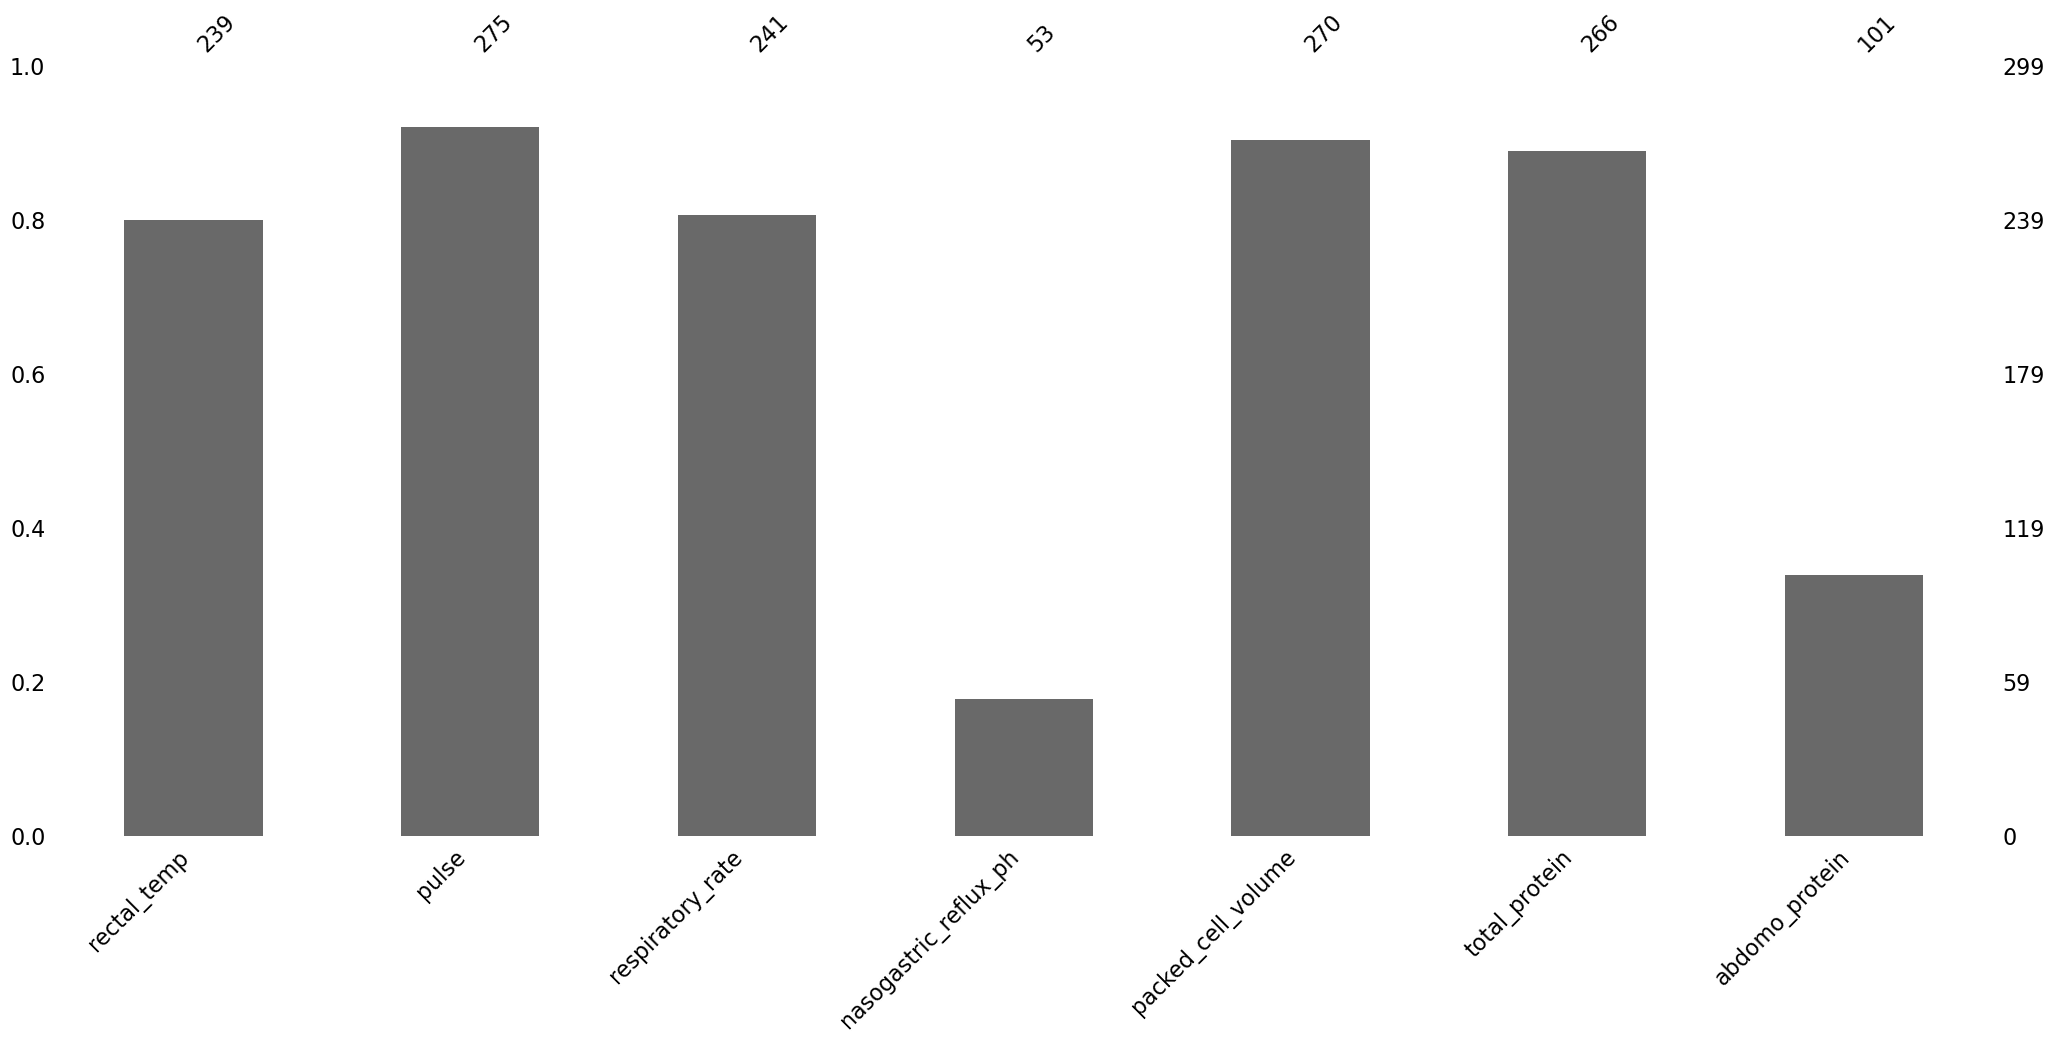

In [72]:
import missingno as msno

msno.bar(numerical_data)

* Tỷ lệ missing values của các features tương đối cao, tuy nhiên missing rate này là tương đối phổ biến và chúng là các signals cho mô hình học được
** Các missing values này thuộc Missing Not At Random (MNAR) cho nên phương pháp mà nhóm chọn để xử lý là : 1. Missing Indicator Variables 2. Gán nhãn 0.  

In [73]:
data_train = data_train.replace("?", np.nan)

for col in numerical_list:
    data_train[f"{col}_missing"] = data_train[col].isna().astype(int)

data_train[numerical_list] = data_train[numerical_list].fillna(0)


In [74]:
object_list = data_train.select_dtypes(include=['object', 'category']).columns.to_list()
object_list

['surgery',
 'age',
 'hospital_number',
 'temp_of_extremities',
 'peripheral_pulse',
 'mucous_membrane',
 'capillary_refill_time',
 'pain',
 'peristalsis',
 'abdominal_distention',
 'nasogastric_tube',
 'nasogastric_reflux',
 'rectal_exam_feces',
 'abdomen',
 'abdomo_appearance',
 'outcome',
 'surgical_lesion',
 'lesion_1',
 'lesion_2',
 'lesion_3',
 'cp_data']

In [75]:
data_train[object_list]

,surgery,age,hospital_number,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,...,nasogastric_reflux,rectal_exam_feces,abdomen,abdomo_appearance,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,cool,reduced,NaN,more_3_sec,extreme_pain,absent,severe,...,NaN,decreased,distend_large,NaN,died,no,11300,0,0,no
1,yes,adult,534817,NaN,NaN,pale_cyanotic,less_3_sec,mild_pain,absent,slight,...,NaN,absent,other,cloudy,euthanized,no,2208,0,0,no
2,no,adult,530334,normal,normal,pale_pink,less_3_sec,mild_pain,hypomotile,none,...,NaN,normal,normal,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,cold,normal,dark_cyanotic,more_3_sec,depressed,absent,severe,...,less_1_liter,decreased,NaN,serosanguious,died,yes,2208,0,0,yes
4,no,adult,530255,NaN,NaN,dark_cyanotic,more_3_sec,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,died,no,4300,0,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,yes,adult,533886,cold,NaN,pale_cyanotic,more_3_sec,depressed,absent,NaN,...,NaN,NaN,distend_large,NaN,euthanized,no,3205,0,0,no
295,no,adult,527702,cool,increased,pale_cyanotic,more_3_sec,severe_pain,hypomotile,moderate,...,none,absent,distend_small,serosanguious,euthanized,yes,2208,0,0,yes
296,yes,adult,529386,cold,reduced,pale_cyanotic,less_3_sec,severe_pain,absent,moderate,...,none,decreased,distend_large,NaN,died,yes,3205,0,0,no
297,yes,adult,530612,cool,reduced,pale_pink,less_3_sec,mild_pain,hypomotile,moderate,...,none,absent,distend_small,serosanguious,lived,yes,2208,0,0,yes


* 1. surgery: chỉ có 2 distinct values (yes/no) -> mapping 
* 2. age: 92 % là adult và 8 % là age -> Dữ liệu phản ánh đúng thực tế -> Encoding 
* 3. Bỏ feature này bởi vì số lượng distinct values lên đến 95 % -> Không mang ý nghĩa dự đoán 
* 4. temp_of_extremities: Nhiệt độ có sự kết nối tuần tự: cold -> cool -> normal -> warm : map thành các số nguyên đúng thứ tự. 
* 5. peripheral_pulse: Có sự kết nối tuần tự: absent -> reduced -> normal -> increased : map thành các số nguyên đúng thứ tự 
* 6. mucous_membrane: One-hot-encoding 
* 7. capillary_refill_time : gộp 3 và less_3_sec thành 1 nhóm , more_3_sec nhóm còn lại, sau đó mapping nhi phân
* 8. peristalsis: one-hot encoding 
* 9. abdominal_distention: Có sự kết nối tuần tự: none ->slight -> moderate -> severe: mapping 
* 10. nasogastric_tube: Có sự kết nối tuần tự: none -> slight -> significant: mapping 
* 11. nasogastic_reflux: One - hot Encoding 
* 12. rectal_exam_feces: có sựu kết nối tuần tự: absent -> normal -> decreased -> increased: mapping 
* 13. abdomen: có sự kết nối tuần tuần tự: mapping 
* 14. outcome là cột mục tiêu 
* 15. surgical_lesion: mapping nhị phân 
* 16. lesion_2 và lesion_3: one-hot encoding 
* 17. lesion_1: Xây dựng hàm giải mã Chữ số cuối cùng: Mã cụ thể (Specific code), Chữ số áp chót: Phân loại phụ (Subtype),Chữ số thứ 3 từ dưới lên: Loại tổn thương (Type), Phần còn lại ở đầu (1 hoặc 2 chữ số): Vị trí (Site).

In [76]:
data_train.drop('hospital_number', axis = 1, inplace = True)

* Xử lý Unknown cho kiểu dữ liệu categorical bằng cách encode -> tính toán giá trị trung bình -> tạo ra một feature (flag)

In [77]:
binary_map = {
    "surgery": {"yes": 1, "no": 0},
    "age": {"adult": 1, "young": 0},
    "surgical_lesion": {"yes": 1, "no": 0},
}

for col, mapping in binary_map.items():
    if col in data_train.columns:
        data_train[col] = data_train[col].map(mapping)

if "capillary_refill_time" in data_train.columns:
    data_train["capillary_refill_time"] = data_train["capillary_refill_time"].map({
        "less_3_sec": 0,
        "3": 0,
        "more_3_sec": 1,
    }).astype(float)

ordinal_maps = {
    "temp_of_extremities": {
        "cold": 0,
        "cool": 1,
        "normal": 2,
        "warm": 3,
    },
    "peripheral_pulse": {
        "absent": 0,
        "reduced": 1,
        "normal": 2,
        "increased": 3,
    },
    "abdominal_distention": {
        "none": 0,
        "slight": 1,
        "moderate": 2,
        "severe": 3,
    },
    "nasogastric_tube": {
        "none": 0,
        "slight": 1,
        "significant": 2,
    },
    "rectal_exam_feces": {
        "absent": 0,
        "normal": 1,
        "decreased": 2,
        "increased": 3,
    },
    "abdomen": {
        "normal": 0,
        "distend_small": 1,
        "other": 2,
        "firm": 3,
        "distend_large": 4,
    },
}

for col, mapping in ordinal_maps.items():
    if col in data_train.columns:
        data_train[col] = data_train[col].map(mapping)

if "pain" in data_train.columns:
    data_train["pain_missing"] = data_train["pain"].isna().astype(int)
    data_train["pain"] = data_train["pain"].fillna("unknown")
    pain_map = {
        "alert": 0,
        "mild_pain": 1,
        "depressed": 2,
        "severe_pain": 3,
        "extreme_pain": 4,
        "unknown": -1,
    }
    data_train["pain"] = data_train["pain"].map(pain_map).astype(int)

if "abdomo_appearance" in data_train.columns:
    data_train["abdomo_appearance_missing"] = data_train["abdomo_appearance"].isna().astype(int)
    data_train["abdomo_appearance"] = data_train["abdomo_appearance"].fillna("unknown")

if "hospital_number" in data_train.columns:
    data_train = data_train.drop(columns=["hospital_number"])

one_hot_cols = [
    "mucous_membrane",
    "peristalsis",
    "nasogastric_reflux",
    "abdomo_appearance",
    "lesion_2",
    "lesion_3",
]
one_hot_cols = [col for col in one_hot_cols if col in data_train.columns]

if one_hot_cols:
    data_train = pd.get_dummies(
        data_train,
        columns=one_hot_cols,
        prefix=one_hot_cols,
        dummy_na=False,
    )


def decode_lesion_1(x):
    if pd.isna(x):
        x = 0

    code = str(int(float(x))).zfill(4)

    site = int(code[:-3]) if code[:-3] != "" else 0
    lesion_type = int(code[-3])
    subtype = int(code[-2])
    specific_code = int(code[-1])

    return pd.Series({
        "lesion_site": site,
        "lesion_type": lesion_type,
        "lesion_subtype": subtype,
        "lesion_specific_code": specific_code,
    })

if "lesion_1" in data_train.columns:
    lesion_decoded = data_train["lesion_1"].apply(decode_lesion_1)
    data_train = pd.concat([data_train.drop(columns=["lesion_1"]), lesion_decoded], axis=1)

y = data_train["outcome"]
X = data_train.drop(columns=["outcome"])

X.head()


,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,capillary_refill_time,pain,abdominal_distention,...,lesion_2_3111,lesion_2_3112,lesion_2_6112,lesion_2_7111,lesion_3_0,lesion_3_2209,lesion_site,lesion_type,lesion_subtype,lesion_specific_code
0,0,1,38.5,66.0,28.0,1.0,1.0,1.0,4,3.0,...,False,False,False,False,True,False,11,3,0,0
1,1,1,39.2,88.0,20.0,NaN,NaN,0.0,1,1.0,...,False,False,False,False,True,False,2,2,0,8
2,0,1,38.3,40.0,24.0,2.0,2.0,0.0,1,0.0,...,False,False,False,False,True,False,0,0,0,0
3,1,0,39.1,164.0,84.0,0.0,2.0,1.0,2,3.0,...,False,False,False,False,True,False,2,2,0,8
4,0,1,37.3,104.0,35.0,NaN,NaN,1.0,-1,NaN,...,False,False,False,False,True,False,4,3,0,0


In [78]:
X

,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,capillary_refill_time,pain,abdominal_distention,...,lesion_2_3111,lesion_2_3112,lesion_2_6112,lesion_2_7111,lesion_3_0,lesion_3_2209,lesion_site,lesion_type,lesion_subtype,lesion_specific_code
0,0,1,38.5,66.0,28.0,1.0,1.0,1.0,4,3.0,...,False,False,False,False,True,False,11,3,0,0
1,1,1,39.2,88.0,20.0,NaN,NaN,0.0,1,1.0,...,False,False,False,False,True,False,2,2,0,8
2,0,1,38.3,40.0,24.0,2.0,2.0,0.0,1,0.0,...,False,False,False,False,True,False,0,0,0,0
3,1,0,39.1,164.0,84.0,0.0,2.0,1.0,2,3.0,...,False,False,False,False,True,False,2,2,0,8
4,0,1,37.3,104.0,35.0,NaN,NaN,1.0,-1,NaN,...,False,False,False,False,True,False,4,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,1,1,0.0,120.0,70.0,0.0,NaN,1.0,2,NaN,...,False,False,False,False,True,False,3,2,0,5
295,0,1,37.2,72.0,24.0,1.0,3.0,1.0,3,2.0,...,False,False,False,False,True,False,2,2,0,8
296,1,1,37.5,72.0,30.0,0.0,1.0,0.0,3,2.0,...,False,False,False,False,True,False,3,2,0,5
297,1,1,36.5,100.0,24.0,1.0,1.0,0.0,1,2.0,...,False,False,False,False,True,False,2,2,0,8


In [79]:
X.to_csv('horse_colic_clean.csv')